# Clustering Tingkat Obesitas dengan K-Means (Metodologi CRISP-DM)

Menerapkan tahapan **CRISP-DM** (Cross Industry Standard Process for Data Mining) untuk melakukan **clustering (unsupervised learning)** terhadap data kebiasaan makan dan gaya hidup, guna menemukan kelompok-kelompok individu yang berkaitan dengan risiko obesitas.

Dataset: `ObesityDataSet_raw_and_data_sinthetic.csv` (UCI Machine Learning Repository - Estimation of Obesity Levels).

## Tentang Dataset

**Sumber dataset:** [UCI Machine Learning Repository - Estimation of Obesity Levels Based On Eating Habits and Physical Condition](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition)

**Alasan pemilihan dataset ini:**
- Dataset ini berisi data kebiasaan makan dan gaya hidup (pola makan, aktivitas fisik, transportasi, konsumsi air, dll.) yang relevan dan realistis untuk mempelajari faktor-faktor yang berkaitan dengan obesitas.
- Memiliki kombinasi fitur **numerik dan kategorikal** yang beragam, sehingga cocok untuk latihan tahapan *data preparation* (encoding & scaling) sebelum proses clustering.
- Jumlah data cukup memadai (2111 baris, 17 kolom) untuk membentuk cluster yang bermakna, namun tetap ringan untuk diproses.
- Terdapat label asli tingkat obesitas (`NObeyesdad`) yang tidak digunakan sebagai fitur clustering, tetapi bisa dimanfaatkan sebagai pembanding (evaluasi eksternal) untuk melihat apakah pola alami dari clustering berkaitan dengan tingkat obesitas sesungguhnya.
- Topik obesitas juga merupakan isu kesehatan yang aktual dan bermanfaat untuk dianalisis lebih lanjut, misalnya untuk keperluan edukasi atau rekomendasi gaya hidup sehat.

## 1. Business Understanding

**Tujuan Bisnis/Penelitian:**
Mengelompokkan individu ke dalam beberapa kelompok (cluster) berdasarkan kebiasaan makan dan gaya hidup mereka, untuk melihat pola-pola umum yang berkaitan dengan risiko obesitas.

Kolom `NObeyesdad` (label tingkat obesitas asli) **tidak digunakan sebagai fitur clustering**, tetapi digunakan di akhir sebagai pembanding untuk melihat apakah cluster yang terbentuk secara alami berkaitan dengan tingkat obesitas.

## 2. Data Understanding

Pada tahap ini kita memuat data, melihat struktur, tipe data, statistik deskriptif, dan sekilas distribusinya.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ObesityDataSet_raw_and_data_sinthetic.csv")
print("Ukuran data:", df.shape)
df.head()

Ukuran data: (2111, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

In [18]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


In [19]:
# Cek missing value dan duplikat
print("Missing value per kolom:")
print(df.isnull().sum())
print("\nJumlah baris duplikat:", df.duplicated().sum())

Missing value per kolom:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Jumlah baris duplikat: 24


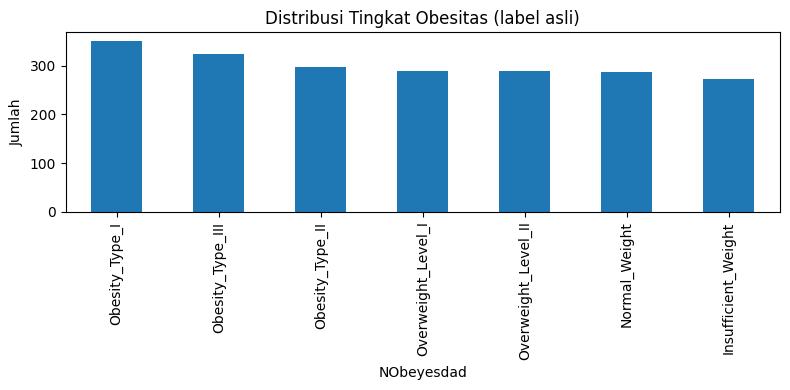

In [20]:
# Distribusi label asli tingkat obesitas
df['NObeyesdad'].value_counts().plot(kind='bar', figsize=(8,4), title='Distribusi Tingkat Obesitas (label asli)')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

## 3. Data Preparation

Langkah yang dilakukan:
1. Membersihkan data duplikat (ditemukan 24 baris duplikat pada tahap Data Understanding).
2. Memisahkan label asli (`NObeyesdad`) dari fitur (tidak dipakai untuk clustering).
3. Encoding kolom kategorikal menjadi angka (Ordinal Encoding).
4. Scaling seluruh fitur numerik agar setiap fitur punya bobot yang setara (penting untuk K-Means yang berbasis jarak).

In [21]:
# Membersihkan baris duplikat
print("Jumlah baris sebelum dibersihkan:", df.shape[0])
df = df.drop_duplicates().reset_index(drop=True)
print("Jumlah baris setelah dibersihkan:", df.shape[0])

Jumlah baris sebelum dibersihkan: 2111
Jumlah baris setelah dibersihkan: 2087


In [22]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

# Simpan label asli terpisah (hanya untuk evaluasi)
label_asli = df['NObeyesdad']
X = df.drop(columns=['NObeyesdad'])

# Identifikasi kolom kategorikal & numerik
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()
print("Kolom kategorikal:", cat_cols)
print("Kolom numerik:", num_cols)

Kolom kategorikal: ['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']
Kolom numerik: ['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']


In [23]:
# Encoding kategorikal -> numerik
encoder = OrdinalEncoder()
X_encoded = X.copy()
X_encoded[cat_cols] = encoder.fit_transform(X_encoded[cat_cols])

# Scaling semua fitur
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_encoded)

print("Data siap untuk clustering, shape:", X_scaled.shape)

Data siap untuk clustering, shape: (2087, 16)


## 4. Modeling

Menentukan jumlah cluster (k) terbaik menggunakan **Elbow Method**, lalu melatih model **K-Means**.

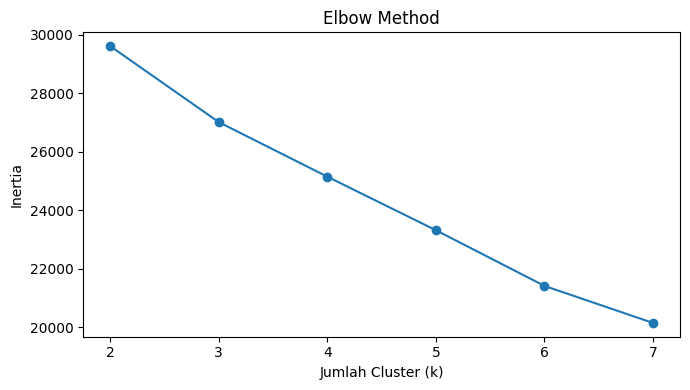

In [24]:
from sklearn.cluster import KMeans

inertia = []
k_range = range(2, 8)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7,4))
plt.plot(list(k_range), inertia, marker='o')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.tight_layout()
plt.show()

In [25]:
# Berdasarkan elbow method, dipilih k = 3
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

df[['Cluster']].value_counts().sort_index()

,count
Cluster,
0,1122
1,441
2,524


## 5. Evaluation

Evaluasi dilakukan dengan dua cara:
1. **Evaluasi internal**: Silhouette Score (seberapa baik pemisahan antar cluster, tanpa label).
2. **Evaluasi eksternal**: membandingkan cluster hasil clustering dengan label asli `NObeyesdad` menggunakan Adjusted Rand Index (ARI), untuk melihat kesesuaian pola.
3. **Profiling cluster**: melihat karakteristik rata-rata tiap cluster.

In [26]:
from sklearn.metrics import silhouette_score, adjusted_rand_score

sil_score = silhouette_score(X_scaled, df['Cluster'])
ari_score = adjusted_rand_score(label_asli, df['Cluster'])

print(f"Silhouette Score : {sil_score:.3f}")
print(f"Adjusted Rand Index (vs label asli) : {ari_score:.3f}")

Silhouette Score : 0.146
Adjusted Rand Index (vs label asli) : 0.124


In [27]:
# Profiling rata-rata fitur numerik per cluster
df.groupby('Cluster')[num_cols].mean().round(2)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
Cluster,,,,,,,,
0,22.89,1.72,100.21,2.46,2.69,2.12,0.95,0.70
1,32.39,1.72,87.38,2.35,2.74,1.96,1.01,0.45
2,20.73,1.64,57.84,2.41,2.70,1.79,1.14,0.76


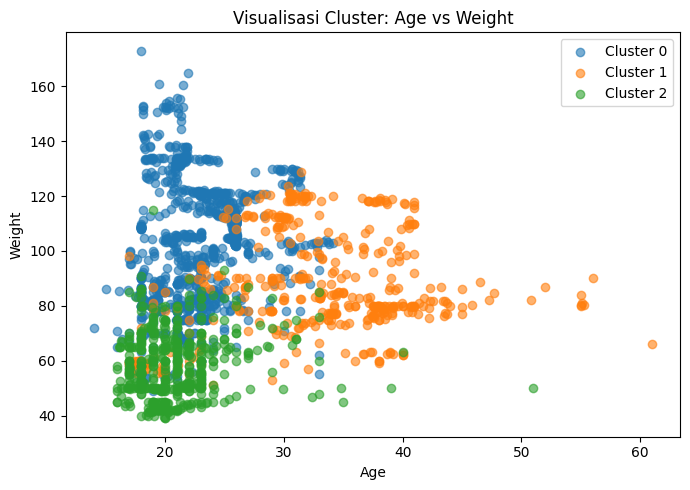

In [28]:
# Visualisasi hubungan Weight vs Age per cluster
plt.figure(figsize=(7,5))
for c in sorted(df['Cluster'].unique()):
    subset = df[df['Cluster'] == c]
    plt.scatter(subset['Age'], subset['Weight'], label=f'Cluster {c}', alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Weight')
plt.title('Visualisasi Cluster: Age vs Weight')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
# Silang cluster dengan label obesitas asli
pd.crosstab(df['Cluster'], label_asli)

NObeyesdad,Insufficient_Weight,Normal_Weight,Obesity_Type_I,Obesity_Type_II,Obesity_Type_III,Overweight_Level_I,Overweight_Level_II
Cluster,,,,,,,
0,28,56,231,199,323,151,134
1,45,26,113,97,1,65,94
2,194,200,7,1,0,60,62


**Interpretasi**
- Nilai Silhouette Score di atas menunjukkan kualitas pemisahan antar cluster (semakin dekat ke 1 semakin baik).
- Tabel *crosstab* di atas menunjukkan bahwa cluster yang terbentuk secara tidak langsung berkaitan dengan tingkat obesitas asli, meskipun clustering dilakukan tanpa melihat label tersebut.
- Dari tabel rata-rata fitur per cluster, kita bisa memberi nama/interpretasi masing-masing cluster (misalnya: cluster dengan rata-rata Weight & Age tinggi serta FAF/aktivitas fisik rendah cenderung berkaitan dengan risiko obesitas lebih tinggi).

## Menyimpan Model untuk Deployment

In [30]:
import joblib

joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(encoder, 'encoder.pkl')
joblib.dump(cat_cols, 'cat_cols.pkl')
joblib.dump(num_cols, 'num_cols.pkl')
joblib.dump(list(X.columns), 'feature_columns.pkl')

print("Model, scaler, dan encoder berhasil disimpan.")

Model, scaler, dan encoder berhasil disimpan.
